# Waitrose Twitter Analysis: BERT Sentiment + Vectorisation + LDA Pipeline

This notebook is a full from-scratch pipeline for the Waitrose Twitter dataset.

It uses:

1. Data loading and cleaning
2. Transformer/BERT-style tokenisation
3. Transformer sentiment classification
4. Positive and negative tweet tables
5. TF-IDF vectorisation for exploratory text structure
6. Count vectorisation + LDA topic modelling for negative tweets
7. Count vectorisation + LDA topic modelling for positive tweets
8. Plots: bar charts, histograms, box plots, scatter plots, heatmaps, and topic charts
9. Exportable CSV tables and figures for the final report

The key improvement over a simple lexicon method is that sentiment is inferred by a pretrained transformer model rather than by counting positive and negative words manually.

## 0. Pipeline Overview

**Goal:** produce a stronger analysis of Waitrose tweets by combining transformer sentiment analysis with vectorised topic modelling.

Pipeline:

```text
waitrose.json
→ load JSON into a dataframe
→ extract full tweet text
→ clean text lightly for BERT sentiment
→ BERT/transformer tokenizer
→ BERT/transformer sentiment model
→ positive / neutral / negative labels
→ sentiment tables and plots
→ split positive and negative tweets
→ vectorise positive tweets
→ LDA topics for positive tweets
→ vectorise negative tweets
→ LDA topics for negative tweets
→ topic tables, representative tweets, and visualisations
→ save all outputs for report writing
```

Important note: vectorisation itself does not create sentiment. It converts text into numbers. Here, sentiment comes from the transformer model, while vectorisation is used for LDA topic modelling and visual exploration.

## 1. Install Dependencies

Run this cell once if the packages are not installed. After installation, restart the kernel if Jupyter asks you to.

In [4]:
# If needed, uncomment and run:
# %pip install -q pandas numpy matplotlib seaborn scikit-learn transformers torch tqdm scipy
import sys
!{sys.executable} -m pip install -q torch transformers pandas numpy matplotlib seaborn scikit-learn tqdm scipy


## 2. Imports And Configuration

In [7]:
from pathlib import Path
import ast
import html
import json
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = Path("waitrose.json")
OUTPUT_DIR = Path("waitrose_bert_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

# BERTweet is designed for tweets and social text.
# If this model is unavailable in your environment, use the fallback listed below.
SENTIMENT_MODEL = "finiteautomata/bertweet-base-sentiment-analysis"
# Fallback option:
# SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"

BATCH_SIZE = 32
MAX_LENGTH = 128

NEGATIVE_TOPIC_COUNT = 6
POSITIVE_TOPIC_COUNT = 6
MAX_FEATURES_LDA = 6000
MAX_FEATURES_TFIDF = 12000

## 3. Load The Waitrose JSON Data

In [8]:
with DATA_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw).reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head(3))
display(pd.DataFrame({"column": df.columns}))

Rows: 24802
Columns: 37


,created_at,id,id_str,text,source,truncated,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,in_reply_to_user_id_str,...,matching_rules,display_text_range,retweeted_status,possibly_sensitive,quoted_status_id,quoted_status_id_str,quoted_status,quoted_status_permalink,extended_entities,scopes
0,1596018538000,1.288421e+18,1.288421e+18,RT @HelpThemHelpUs_: Our friends at @Potsandco...,"<a href=""http://twitter.com/download/iphone"" r...",False,NaN,NaN,NaN,NaN,...,[{'tag': None}],None,{'created_at': 'Tue Jul 28 16:29:56 +0000 2020...,None,NaN,NaN,None,None,None,None
1,1605630679000,1.328737e+18,1.328737e+18,@HOOODINIIII @roh17h @Samuel51 @sainsburys @Ma...,"<a href=""http://twitter.com/download/iphone"" r...",False,1.328654e+18,1.328654e+18,1.327758e+18,1.327758e+18,...,[{'tag': None}],"[57, 133]",None,None,NaN,NaN,None,None,None,None
2,1582921141000,1.233487e+18,1.233487e+18,@waitrose the wine you delivered yesterday was...,"<a href=""http://twitter.com/download/iphone"" r...",False,NaN,NaN,4.632874e+07,4.632874e+07,...,[{'tag': None}],None,None,None,NaN,NaN,None,None,None,None


,column
0,created_at
1,id
2,id_str
3,text
4,source
5,truncated
6,in_reply_to_status_id
7,in_reply_to_status_id_str
8,in_reply_to_user_id
9,in_reply_to_user_id_str


## 4. Parse Tweet Text And Metadata

In [9]:
def parse_maybe_dict(value):
    if pd.isna(value):
        return None
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            return None
    return None


def clean_spaces(text):
    text = html.unescape(str(text or ""))
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def extract_full_text(row):
    extended = parse_maybe_dict(row.get("extended_tweet"))
    if extended and extended.get("full_text"):
        return clean_spaces(extended["full_text"])

    retweeted = parse_maybe_dict(row.get("retweeted_status"))
    if retweeted:
        rt_extended = retweeted.get("extended_tweet") or {}
        user = retweeted.get("user") or {}
        screen_name = user.get("screen_name", "")
        if isinstance(rt_extended, dict) and rt_extended.get("full_text"):
            return clean_spaces(f"RT @{screen_name}: {rt_extended['full_text']}")
        if retweeted.get("text"):
            return clean_spaces(f"RT @{screen_name}: {retweeted['text']}")

    return clean_spaces(row.get("text", ""))


def extract_mentions(entity_value):
    ent = parse_maybe_dict(entity_value) or {}
    mentions = []
    for m in ent.get("user_mentions", []) or []:
        sn = m.get("screen_name")
        if sn:
            mentions.append(sn.lower())
    return mentions


def extract_hashtags(entity_value):
    ent = parse_maybe_dict(entity_value) or {}
    hashtags = []
    for h in ent.get("hashtags", []) or []:
        tag = h.get("text")
        if tag:
            hashtags.append(tag.lower())
    return hashtags


df["text_full"] = df.apply(extract_full_text, axis=1)
df["datetime_utc"] = pd.to_datetime(df["created_at"], unit="ms", utc=True)
df["date"] = df["datetime_utc"].dt.date.astype(str)
df["month"] = df["datetime_utc"].dt.to_period("M").astype(str)
df["source_clean"] = df["source"].fillna("").str.replace(r"<[^>]+>", "", regex=True)
df["is_retweet"] = df["text_full"].str.startswith("RT @")
df["is_reply"] = df["in_reply_to_status_id"].notna() | df["in_reply_to_screen_name"].notna()
df["mentions"] = df["entities"].apply(extract_mentions)
df["hashtags"] = df["entities"].apply(extract_hashtags)

for col in ["quote_count", "reply_count", "retweet_count", "favorite_count"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

df["total_engagement"] = df[["quote_count", "reply_count", "retweet_count", "favorite_count"]].sum(axis=1)
df["text_length"] = df["text_full"].str.len()
df["word_count"] = df["text_full"].str.split().str.len()

print("Date range:", df["date"].min(), "to", df["date"].max())
print("Tweets:", len(df))
print("Retweets:", int(df["is_retweet"].sum()))
print("Replies:", int(df["is_reply"].sum()))
display(df[["date", "text_full", "is_retweet", "is_reply", "total_engagement", "mentions", "hashtags"]].head())

Date range: 2020-01-01 to 2020-12-30
Tweets: 24802
Retweets: 9797
Replies: 11291


,date,text_full,is_retweet,is_reply,total_engagement,mentions,hashtags
0,2020-07-29,RT @theHWF: Our friends at @Potsandco puddings...,True,False,0,"[helpthemhelpus_, potsandco]",[]
1,2020-11-17,@HOOODINIIII @roh17h @Samuel51 @sainsburys @Ma...,False,True,1,"[hooodiniiii, roh17h, samuel51, sainsburys, ma...",[]
2,2020-02-28,@waitrose the wine you delivered yesterday was...,False,True,1,[waitrose],[]
3,2020-11-13,RT @JohnLewisRetail: This Christmas we want to...,True,False,0,"[jlandpartners, waitrose]",[givealittlelove]
4,2020-06-04,RT @RebeccaTillett1: @waitrose if the U.K. ach...,True,False,0,"[rebeccatillett1, waitrose]",[]


## 5. Clean Text For BERT Sentiment

For transformer sentiment, cleaning should be light. Do not remove too much context.

This version:

- replaces URLs with `HTTPURL`
- replaces usernames with `@USER`
- keeps hashtags as words
- keeps punctuation because transformer models can use it

In [10]:
def clean_for_bert(text):
    text = html.unescape(str(text))
    text = re.sub(r"https?://\S+|www\.\S+", "HTTPURL", text)
    text = re.sub(r"@\w+", "@USER", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df["text_bert"] = df["text_full"].apply(clean_for_bert)
display(df[["text_full", "text_bert"]].head(10))

,text_full,text_bert
0,RT @theHWF: Our friends at @Potsandco puddings...,RT @USER: Our friends at @USER puddings are do...
1,@HOOODINIIII @roh17h @Samuel51 @sainsburys @Ma...,@USER @USER @USER @USER @USER I go to @USER to...
2,@waitrose the wine you delivered yesterday was...,@USER the wine you delivered yesterday was off...
3,RT @JohnLewisRetail: This Christmas we want to...,RT @USER: This Christmas we want to GiveALittl...
4,RT @RebeccaTillett1: @waitrose if the U.K. ach...,RT @USER: @USER if the U.K. achieves a trade d...
5,@Peterkay2k11 @Morrisons @Tesco @sainsburys @a...,@USER @USER @USER @USER @USER @USER @USER @USE...
6,@DrJDrooghaag @GeekOnTheLoose @digitalcloudgal...,@USER @USER @USER @USER @USER @USER @USER @USE...
7,@NLeespeaking @laworfiction @waitrose @Francis...,@USER @USER @USER @USER How do you know this m...
8,@serichards @waitrose @InstaVoltUK @engenieUK ...,@USER @USER @USER @USER .@USER Let's do some e...
9,@mcgjingsorbust @waitrose We used to enjoy the...,@USER @USER We used to enjoy the Waitrose Leck...


## 6. BERT-Style Tokenisation

This is where the notebook uses the model tokenizer. Unlike the earlier rule-based tokenizer, this tokenizer is learned from the transformer's vocabulary.

The tokenizer converts text into:

- `input_ids`
- `attention_mask`
- subword tokens

Example: one tweet can become many subword pieces depending on the tokenizer vocabulary.

In [11]:
tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL, use_fast=False)

example_text = df.loc[0, "text_bert"]
encoded = tokenizer(
    example_text,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH,
    return_tensors="pt",
)

tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

print("Original tweet:")
print(example_text)
print("\nFirst 60 tokenizer tokens:")
print(tokens[:60])
print("\nToken tensor shape:", encoded["input_ids"].shape)

config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/338 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Original tweet:
RT @USER: Our friends at @USER puddings are donating all profits from sales of its delicious new Tiramisu to HEROES and @USER 💙 Get yours @USER now NHSworkers HTTPURL

First 60 tokenizer tokens:
['<s>', 'RT', '@@@', 'US@@', 'ER@@', ':', 'Our', 'friends', 'at', '@USER', 'pu@@', 'dd@@', 'ings', 'are', 'donating', 'all', 'profits', 'from', 'sales', 'of', 'its', 'delicious', 'new', 'Tir@@', 'am@@', 'is@@', 'u', 'to', 'HER@@', 'OES', 'and', '@USER', '<unk>', 'Get', 'yours', '@USER', 'now', 'N@@', 'HS@@', 'workers', 'HTTPURL', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Token tensor shape: torch.Size([1, 128])


## 7. Transformer Sentiment Analysis

This step uses a pretrained transformer sequence-classification model.

To avoid rerunning the model every time, predictions are cached to:

`waitrose_bert_outputs/bert_sentiment_predictions.csv`

In [12]:
sentiment_cache = OUTPUT_DIR / "bert_sentiment_predictions.csv"


def normalise_label(label):
    label = str(label).lower()
    mapping = {
        "label_0": "negative",
        "label_1": "neutral",
        "label_2": "positive",
        "neg": "negative",
        "negative": "negative",
        "neu": "neutral",
        "neutral": "neutral",
        "pos": "positive",
        "positive": "positive",
    }
    return mapping.get(label, label)


if sentiment_cache.exists():
    pred_df = pd.read_csv(sentiment_cache)
    df = df.merge(pred_df, left_index=True, right_on="row_id", how="left").set_index("row_id", drop=True)
    df.index.name = None
    print("Loaded cached BERT sentiment predictions.")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL)
    model.to(device)
    model.eval()

    labels = []
    confidences = []
    negative_probs = []
    neutral_probs = []
    positive_probs = []

    texts = df["text_bert"].tolist()

    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc="BERT sentiment"):
        batch = texts[start:start + BATCH_SIZE]
        inputs = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1).detach().cpu().numpy()

        for p in probs:
            pred_idx = int(np.argmax(p))
            raw_label = model.config.id2label[pred_idx]
            label = normalise_label(raw_label)

            # Robust probability mapping.
            label_names = [normalise_label(model.config.id2label[i]) for i in range(len(p))]
            prob_map = {name: float(p[i]) for i, name in enumerate(label_names)}

            labels.append(label)
            confidences.append(float(np.max(p)))
            negative_probs.append(prob_map.get("negative", np.nan))
            neutral_probs.append(prob_map.get("neutral", np.nan))
            positive_probs.append(prob_map.get("positive", np.nan))

    df["bert_sentiment"] = labels
    df["bert_confidence"] = confidences
    df["prob_negative"] = negative_probs
    df["prob_neutral"] = neutral_probs
    df["prob_positive"] = positive_probs

    pred_df = df[["bert_sentiment", "bert_confidence", "prob_negative", "prob_neutral", "prob_positive"]].copy()
    pred_df.insert(0, "row_id", pred_df.index)
    pred_df.to_csv(sentiment_cache, index=False)
    print("Saved:", sentiment_cache)

display(df[["text_full", "bert_sentiment", "bert_confidence", "prob_negative", "prob_neutral", "prob_positive"]].head())

Using device: cpu


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT sentiment:   0%|          | 0/776 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Saved: waitrose_bert_outputs/bert_sentiment_predictions.csv


,text_full,bert_sentiment,bert_confidence,prob_negative,prob_neutral,prob_positive
0,RT @theHWF: Our friends at @Potsandco puddings...,positive,0.979464,0.000905,0.019632,0.979464
1,@HOOODINIIII @roh17h @Samuel51 @sainsburys @Ma...,positive,0.927073,0.000998,0.071929,0.927073
2,@waitrose the wine you delivered yesterday was...,negative,0.980687,0.980687,0.015986,0.003327
3,RT @JohnLewisRetail: This Christmas we want to...,positive,0.983550,0.001077,0.015372,0.983550
4,RT @RebeccaTillett1: @waitrose if the U.K. ach...,neutral,0.948675,0.017320,0.948675,0.034006


## 8. Sentiment Tables: Positive And Negative Tweets

In [13]:
sentiment_summary = (
    df["bert_sentiment"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="tweet_count")
)
sentiment_summary["percent"] = sentiment_summary["tweet_count"] / len(df) * 100
sentiment_summary = sentiment_summary.sort_values("sentiment")

sentiment_engagement = (
    df.groupby("bert_sentiment")
    .agg(
        tweets=("text_full", "count"),
        avg_confidence=("bert_confidence", "mean"),
        avg_engagement=("total_engagement", "mean"),
        median_engagement=("total_engagement", "median"),
        total_likes=("favorite_count", "sum"),
        total_retweets=("retweet_count", "sum"),
        total_replies=("reply_count", "sum"),
        total_quotes=("quote_count", "sum"),
    )
    .reset_index()
)

positive_tweets = (
    df[df["bert_sentiment"] == "positive"]
    .sort_values(["bert_confidence", "total_engagement"], ascending=False)
    [["date", "text_full", "bert_confidence", "prob_positive", "total_engagement", "favorite_count", "retweet_count", "reply_count"]]
)

negative_tweets = (
    df[df["bert_sentiment"] == "negative"]
    .sort_values(["bert_confidence", "total_engagement"], ascending=False)
    [["date", "text_full", "bert_confidence", "prob_negative", "total_engagement", "favorite_count", "retweet_count", "reply_count"]]
)

sentiment_summary.to_csv(OUTPUT_DIR / "sentiment_summary_bert.csv", index=False)
sentiment_engagement.to_csv(OUTPUT_DIR / "sentiment_engagement_bert.csv", index=False)
positive_tweets.to_csv(OUTPUT_DIR / "positive_tweets_table.csv", index=False)
negative_tweets.to_csv(OUTPUT_DIR / "negative_tweets_table.csv", index=False)

print("BERT sentiment summary")
display(sentiment_summary)

print("Engagement by sentiment")
display(sentiment_engagement)

print("Top positive tweets")
display(positive_tweets.head(15))

print("Top negative tweets")
display(negative_tweets.head(15))

BERT sentiment summary


,sentiment,tweet_count,percent
2,negative,6123,24.687525
1,neutral,9107,36.718813
0,positive,9572,38.593662


Engagement by sentiment


,bert_sentiment,tweets,avg_confidence,avg_engagement,median_engagement,total_likes,total_retweets,total_replies,total_quotes
0,negative,6123,0.870957,1.885024,0.0,7228,1202,2937,175
1,neutral,9107,0.821912,2.935434,0.0,19689,3088,3406,550
2,positive,9572,0.897774,3.693899,0.0,27427,4282,2960,689


Top positive tweets


,date,text_full,bert_confidence,prob_positive,total_engagement,favorite_count,retweet_count,reply_count
17570,2020-11-20,Have you seen the new @waitrose Christmas adve...,0.993258,0.993258,0,0,0,0
5065,2020-05-15,@OliviaHuse @thatpubblogger @waitrose Yes! A f...,0.993240,0.993240,3,2,0,1
8237,2020-10-28,@TheGutHealthDoc @bioandmeuk @waitrose We're l...,0.993228,0.993228,2,1,0,1
22370,2020-04-27,RT @dataimagegroup: We’re just loving this fan...,0.993220,0.993220,0,0,0,0
3740,2020-11-13,Tissues ready...the John Lewis ad is even more...,0.993208,0.993208,1,0,0,1
461,2020-01-08,RT @JoMartindale: Thankyou @waitrose hove for ...,0.993193,0.993193,0,0,0,0
21708,2020-01-07,RT @JoMartindale: Thankyou @waitrose hove for ...,0.993193,0.993193,0,0,0,0
20586,2020-07-06,@waitrose I put my winning voucher to good use...,0.993189,0.993189,1,1,0,0
17376,2020-11-13,@jlandpartners @waitrose @homestartuk @FareSha...,0.993185,0.993185,19,18,0,1
10807,2020-01-17,So excited by my morning of freebies. Books an...,0.993174,0.993174,4,3,0,1


Top negative tweets


,date,text_full,bert_confidence,prob_negative,total_engagement,favorite_count,retweet_count,reply_count
5772,2020-01-10,@waitrose SHOCKING!!!!!! HIT & RUN LORRY DRIVE...,0.984096,0.984096,0,0,0,0
1442,2020-03-08,@scumfc1005 @bbcburnsy @shunty75 @waitrose Idi...,0.983862,0.983862,1,1,0,0
8056,2020-12-24,RT @ZipWireWoman: @waitrose Contemptible scum ...,0.983294,0.983294,0,0,0,0
9467,2020-11-25,@waitrose disgusting attitude with the store m...,0.983281,0.983281,1,0,0,1
10418,2020-07-26,@waitrose get this idiot banned. He’s vermin. ...,0.983220,0.983220,0,0,0,0
20239,2020-05-22,@waitrose @ITV Fuck you waitrose. Not buying f...,0.983151,0.983151,0,0,0,0
11616,2020-07-12,@stevehunt4hiop @waitrose You are truly pathet...,0.983144,0.983144,3,3,0,0
21097,2020-03-14,@waitrose your customer toilets in #Finchley A...,0.983100,0.983100,1,0,0,1
15629,2020-12-30,@hannahthompso @waitrose @sainsburys @Tesco @B...,0.983084,0.983084,0,0,0,0
8209,2020-05-30,@rspcaessexsth @waitrose @EssexPoliceUK @RSPCA...,0.982972,0.982972,2,1,1,0


## 9. Sentiment Visualisations

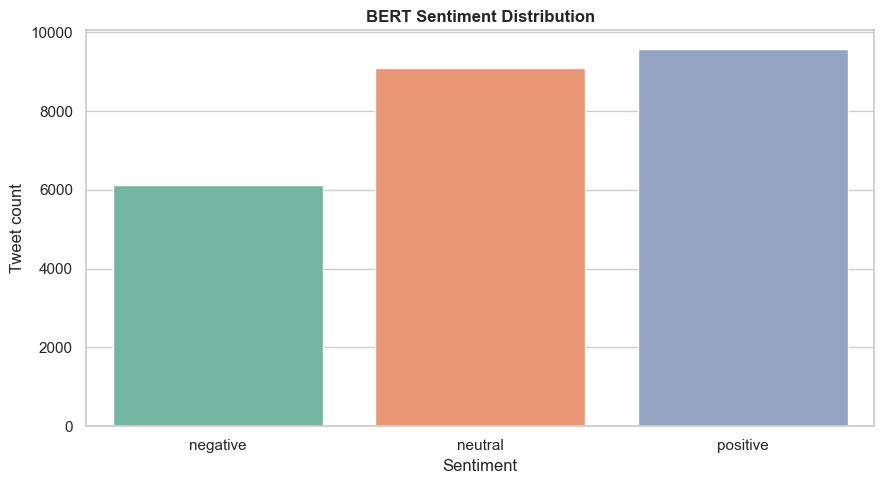

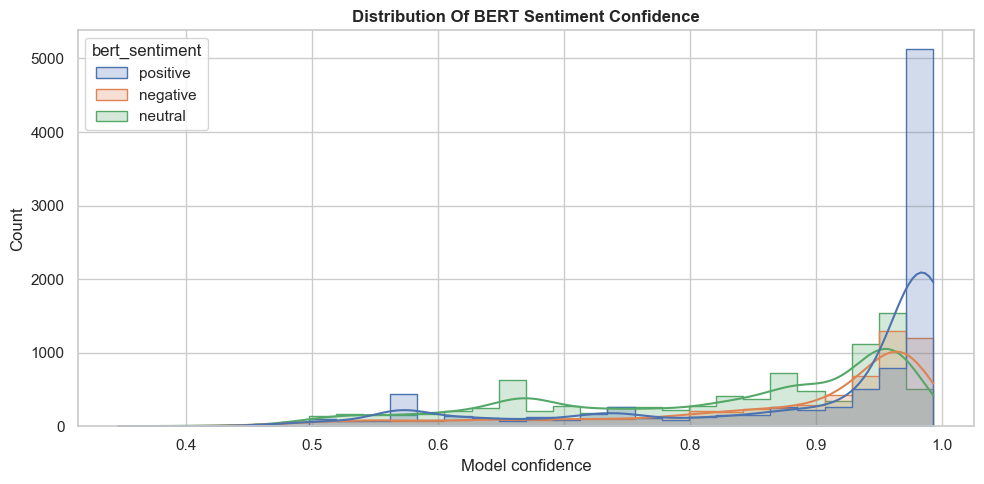

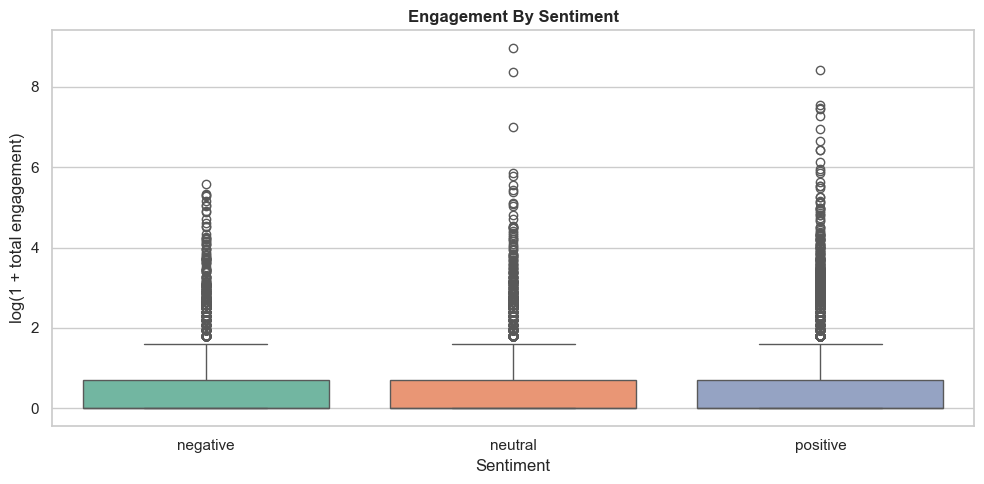

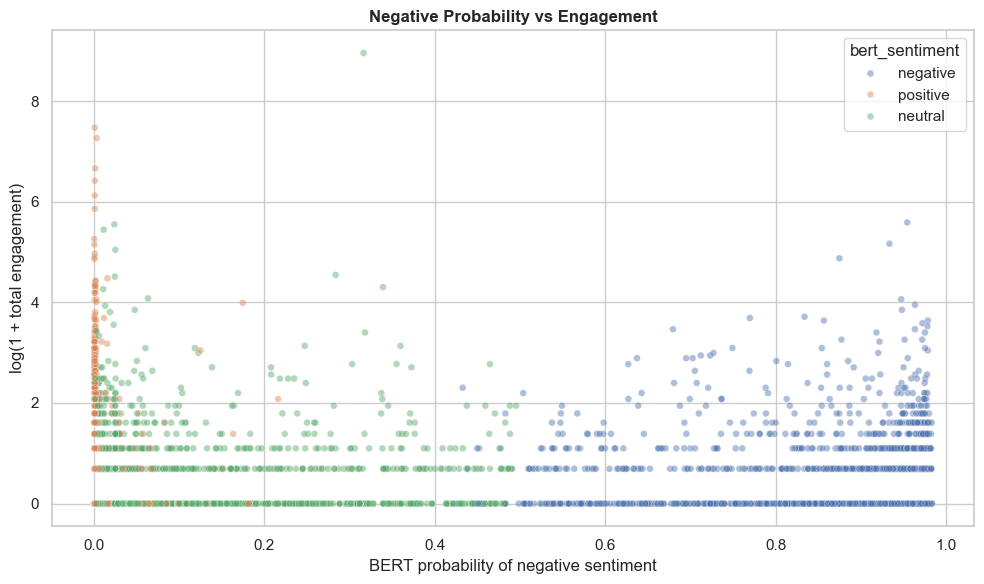

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x="bert_sentiment", order=["negative", "neutral", "positive"], palette="Set2", ax=ax)
ax.set_title("BERT Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Tweet count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_sentiment_count.png", dpi=200)
plt.show()


fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="bert_confidence", hue="bert_sentiment", bins=30, kde=True, element="step", ax=ax)
ax.set_title("Distribution Of BERT Sentiment Confidence")
ax.set_xlabel("Model confidence")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_sentiment_confidence_histogram.png", dpi=200)
plt.show()


plot_df = df.copy()
plot_df["log_engagement"] = np.log1p(plot_df["total_engagement"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x="bert_sentiment", y="log_engagement", order=["negative", "neutral", "positive"], palette="Set2", ax=ax)
ax.set_title("Engagement By Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("log(1 + total engagement)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_engagement_boxplot_by_sentiment.png", dpi=200)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))
sample_scatter = df.sample(min(len(df), 7000), random_state=RANDOM_STATE).copy()
sample_scatter["log_engagement"] = np.log1p(sample_scatter["total_engagement"])
sns.scatterplot(
    data=sample_scatter,
    x="prob_negative",
    y="log_engagement",
    hue="bert_sentiment",
    alpha=0.45,
    s=24,
    ax=ax,
)
ax.set_title("Negative Probability vs Engagement")
ax.set_xlabel("BERT probability of negative sentiment")
ax.set_ylabel("log(1 + total engagement)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_negative_probability_scatter.png", dpi=200)
plt.show()

## 10. Monthly Sentiment Heatmap

bert_sentiment,negative,neutral,positive
month,,,
2020-01,176,244,321
2020-02,219,287,327
2020-03,1467,1939,1486
2020-04,823,750,1375
2020-05,213,299,511
2020-06,465,650,978
2020-07,574,1476,522
2020-08,252,311,311
2020-09,439,429,371


bert_sentiment,negative,neutral,positive
month,,,
2020-01,23.75,32.93,43.32
2020-02,26.29,34.45,39.26
2020-03,29.99,39.64,30.38
2020-04,27.92,25.44,46.64
2020-05,20.82,29.23,49.95
2020-06,22.22,31.06,46.73
2020-07,22.32,57.39,20.30
2020-08,28.83,35.58,35.58
2020-09,35.43,34.62,29.94


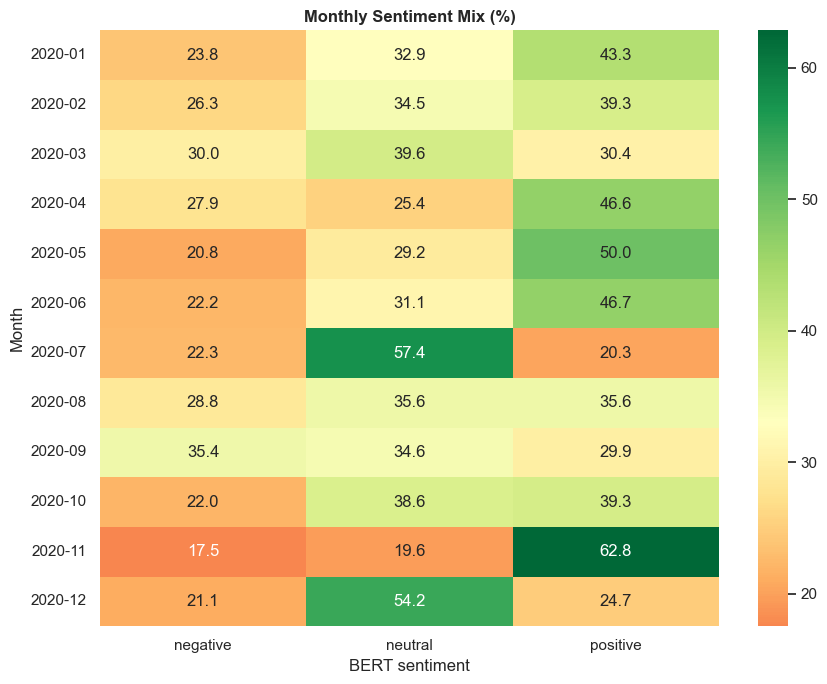

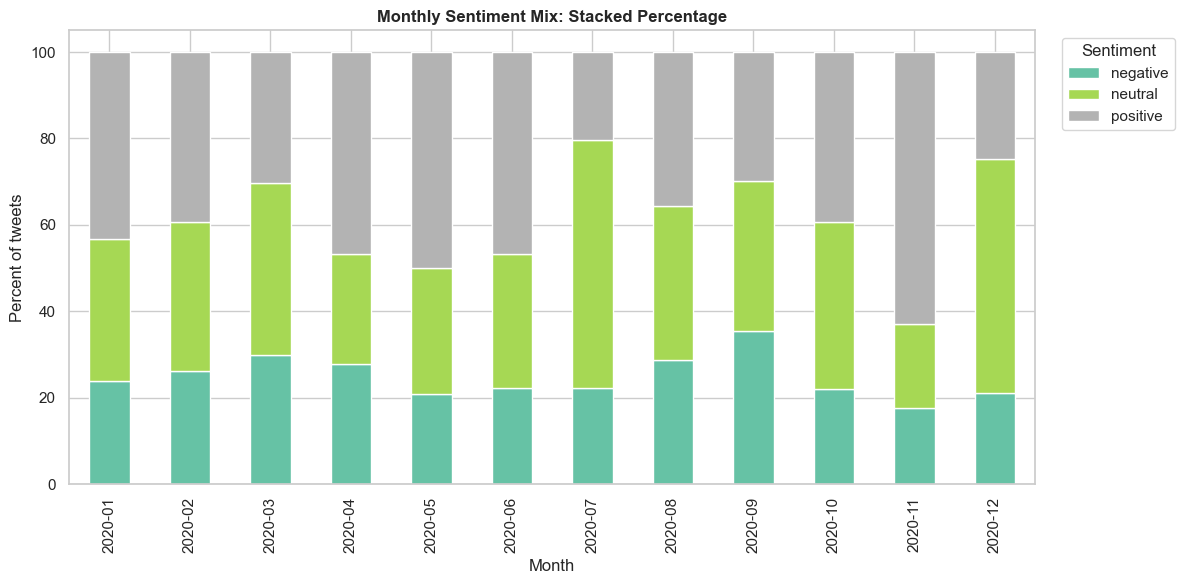

In [15]:
monthly_sentiment = pd.crosstab(df["month"], df["bert_sentiment"])
for col in ["negative", "neutral", "positive"]:
    if col not in monthly_sentiment.columns:
        monthly_sentiment[col] = 0
monthly_sentiment = monthly_sentiment[["negative", "neutral", "positive"]]
monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0) * 100

monthly_sentiment.to_csv(OUTPUT_DIR / "monthly_sentiment_counts_bert.csv")
monthly_sentiment_pct.to_csv(OUTPUT_DIR / "monthly_sentiment_percent_bert.csv")

display(monthly_sentiment)
display(monthly_sentiment_pct.round(2))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(monthly_sentiment_pct, annot=True, fmt=".1f", cmap="RdYlGn", center=33, ax=ax)
ax.set_title("Monthly Sentiment Mix (%)")
ax.set_xlabel("BERT sentiment")
ax.set_ylabel("Month")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_monthly_sentiment_heatmap.png", dpi=200)
plt.show()


monthly_sentiment_pct.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")
plt.title("Monthly Sentiment Mix: Stacked Percentage")
plt.xlabel("Month")
plt.ylabel("Percent of tweets")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_monthly_sentiment_stacked_bar.png", dpi=200)
plt.show()

## 11. Topic Cleaning For Vectorisation And LDA

The BERT sentiment model used lightly cleaned text. LDA needs heavier cleaning so that topics are formed from meaningful terms rather than URLs, mentions, or repeated brand handles.

In [16]:
CUSTOM_STOPWORDS = {
    "waitrose", "amp", "httpurl", "user", "https", "http", "co", "rt",
    "please", "thanks", "thank", "hi", "hello", "today", "get", "got",
    "would", "could", "also", "really", "just", "one", "like", "still",
    "ive", "im", "youre", "weve", "dont", "cant", "isnt", "doesnt",
}


def clean_for_topics(text):
    text = html.unescape(str(text).lower())
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\b\w{1,2}\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["text_topic"] = df["text_bert"].apply(clean_for_topics)

negative_df = df[df["bert_sentiment"] == "negative"].copy()
positive_df = df[df["bert_sentiment"] == "positive"].copy()

print("Negative tweets:", len(negative_df))
print("Positive tweets:", len(positive_df))
display(df[["text_bert", "text_topic"]].head())

Negative tweets: 6123
Positive tweets: 9572


,text_bert,text_topic
0,RT @USER: Our friends at @USER puddings are do...,our friends puddings are donating all profits ...
1,@USER @USER @USER @USER @USER I go to @USER to...,too but definitely shopping more
2,@USER the wine you delivered yesterday was off...,the wine you delivered yesterday was off and h...
3,RT @USER: This Christmas we want to GiveALittl...,this christmas want givealittlelove with becau...
4,RT @USER: @USER if the U.K. achieves a trade d...,the achieves trade deal with the will waitrose...


## 12. TF-IDF Vectorisation And 2D Scatter

TF-IDF is used here to inspect structure in the tweet text. The scatter plot projects high-dimensional TF-IDF vectors down to two dimensions using TruncatedSVD.

TF-IDF shape: (24802, 12000)


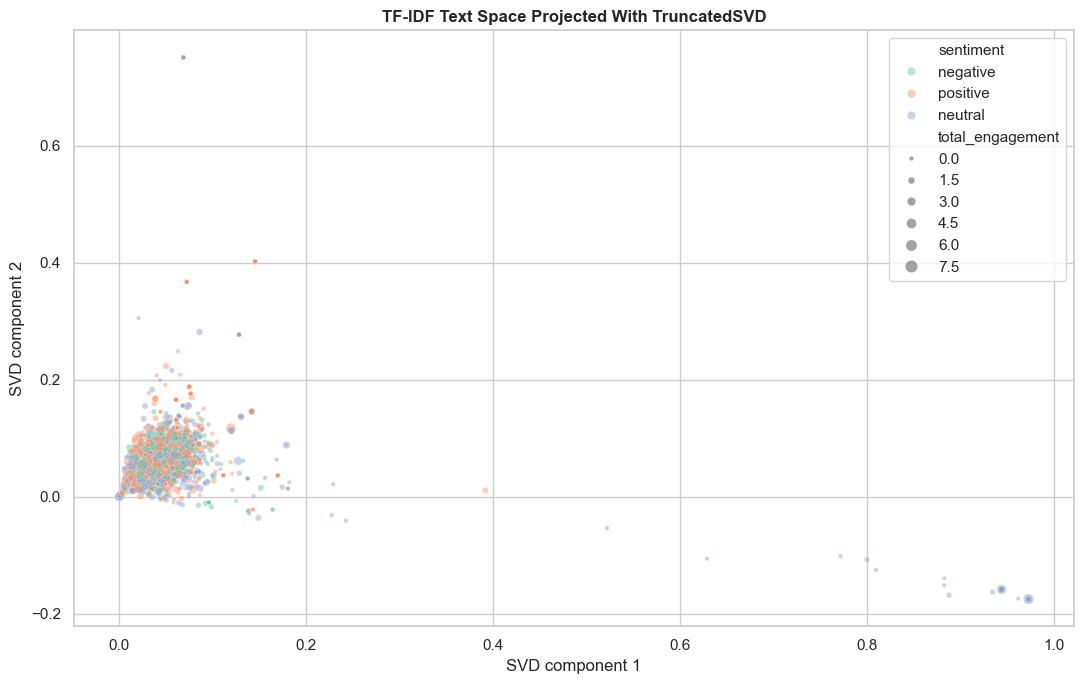

In [17]:
tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES_TFIDF,
    stop_words=list(CUSTOM_STOPWORDS),
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.80,
)

X_tfidf = tfidf.fit_transform(df["text_topic"])
print("TF-IDF shape:", X_tfidf.shape)

svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd.fit_transform(X_tfidf)

svd_df = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "sentiment": df["bert_sentiment"].values,
    "prob_negative": df["prob_negative"].values,
    "total_engagement": df["total_engagement"].values,
})

sample_svd = svd_df.sample(min(len(svd_df), 8000), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=sample_svd,
    x="x",
    y="y",
    hue="sentiment",
    size=np.log1p(sample_svd["total_engagement"]),
    sizes=(10, 90),
    alpha=0.45,
    palette="Set2",
    ax=ax,
)
ax.set_title("TF-IDF Text Space Projected With TruncatedSVD")
ax.set_xlabel("SVD component 1")
ax.set_ylabel("SVD component 2")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_tfidf_svd_scatter.png", dpi=200)
plt.show()

## 13. Top TF-IDF Terms By Sentiment

Top negative TF-IDF terms


,term,mean_tfidf
0,the,0.041374
1,you,0.031821
2,and,0.031073
3,not,0.025664
4,are,0.024804
5,that,0.022668
6,for,0.022359
7,they,0.022352
8,have,0.020259
9,this,0.020086


Top positive TF-IDF terms


,term,mean_tfidf
0,you,0.041206
1,the,0.036829
2,and,0.032311
3,this,0.030948
4,for,0.028966
5,with,0.024980
6,our,0.024853
7,christmas,0.019624
8,all,0.019493
9,love,0.016453


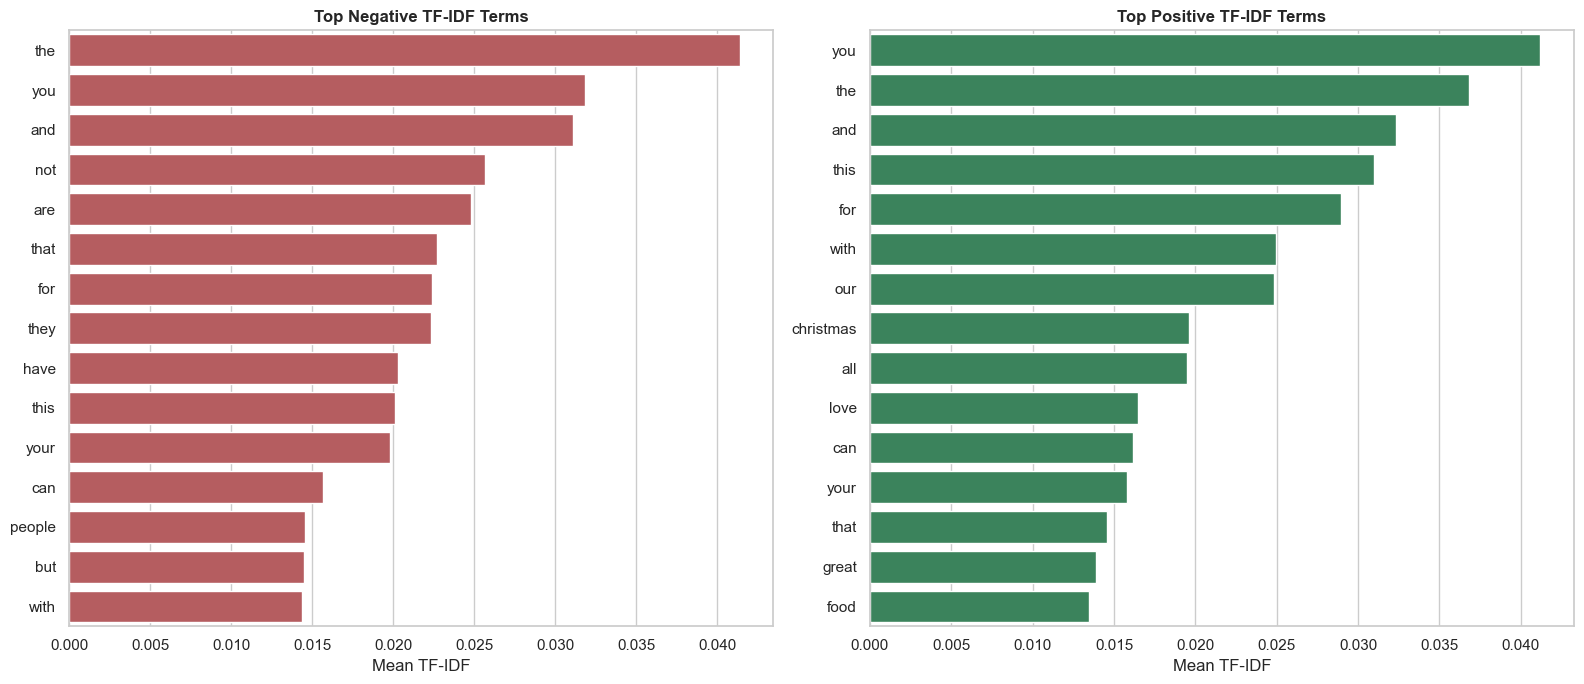

In [18]:
terms = np.array(tfidf.get_feature_names_out())

def top_mean_tfidf(mask, top_n=30):
    X_sub = X_tfidf[mask]
    mean_scores = np.asarray(X_sub.mean(axis=0)).ravel()
    idx = mean_scores.argsort()[::-1][:top_n]
    return pd.DataFrame({"term": terms[idx], "mean_tfidf": mean_scores[idx]})

top_negative_terms = top_mean_tfidf(df["bert_sentiment"].eq("negative").values)
top_positive_terms = top_mean_tfidf(df["bert_sentiment"].eq("positive").values)

top_negative_terms.to_csv(OUTPUT_DIR / "top_negative_tfidf_terms.csv", index=False)
top_positive_terms.to_csv(OUTPUT_DIR / "top_positive_tfidf_terms.csv", index=False)

print("Top negative TF-IDF terms")
display(top_negative_terms)

print("Top positive TF-IDF terms")
display(top_positive_terms)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=top_negative_terms.head(15), y="term", x="mean_tfidf", ax=axes[0], color="#c44e52")
axes[0].set_title("Top Negative TF-IDF Terms")
axes[0].set_xlabel("Mean TF-IDF")
axes[0].set_ylabel("")

sns.barplot(data=top_positive_terms.head(15), y="term", x="mean_tfidf", ax=axes[1], color="#2f8f5b")
axes[1].set_title("Top Positive TF-IDF Terms")
axes[1].set_xlabel("Mean TF-IDF")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_top_tfidf_terms_by_sentiment.png", dpi=200)
plt.show()

## 14. LDA Helper Functions

LDA should use raw count vectors, not TF-IDF, because LDA is a probabilistic word-count model.

We will run two separate LDA models:

1. negative tweets only
2. positive tweets only

In [19]:
def fit_lda_topic_model(
    subset_df,
    text_col="text_topic",
    n_topics=6,
    max_features=6000,
    min_df=3,
    max_df=0.80,
    random_state=42,
):
    vectorizer = CountVectorizer(
        max_features=max_features,
        stop_words=list(CUSTOM_STOPWORDS),
        ngram_range=(1, 2),
        min_df=min_df,
        max_df=max_df,
    )

    X = vectorizer.fit_transform(subset_df[text_col])
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        learning_method="batch",
        random_state=random_state,
        max_iter=25,
        evaluate_every=5,
        n_jobs=-1,
    )
    doc_topic = lda.fit_transform(X)
    feature_names = np.array(vectorizer.get_feature_names_out())
    return vectorizer, X, lda, doc_topic, feature_names


def topic_word_table(lda, feature_names, top_n=18, prefix="topic"):
    rows = []
    for topic_idx, topic in enumerate(lda.components_):
        top_idx = topic.argsort()[::-1][:top_n]
        rows.append({
            "topic_id": topic_idx + 1,
            "topic_name": f"{prefix}_{topic_idx + 1}",
            "top_words": ", ".join(feature_names[top_idx]),
        })
    return pd.DataFrame(rows)


def assign_topics(subset_df, doc_topic):
    out = subset_df.copy()
    out["lda_topic_id"] = doc_topic.argmax(axis=1) + 1
    out["lda_topic_probability"] = doc_topic.max(axis=1)
    return out


def topic_prevalence_table(assigned_df):
    table = (
        assigned_df["lda_topic_id"]
        .value_counts()
        .sort_index()
        .rename_axis("topic_id")
        .reset_index(name="tweet_count")
    )
    table["percent"] = table["tweet_count"] / table["tweet_count"].sum() * 100
    return table


def representative_tweets(assigned_df, top_n=5):
    rows = []
    for topic_id, group in assigned_df.groupby("lda_topic_id"):
        top = group.sort_values(["lda_topic_probability", "total_engagement"], ascending=False).head(top_n)
        for _, row in top.iterrows():
            rows.append({
                "topic_id": topic_id,
                "date": row["date"],
                "probability": row["lda_topic_probability"],
                "total_engagement": row["total_engagement"],
                "tweet": row["text_full"],
            })
    return pd.DataFrame(rows)

## 15. LDA For Negative Tweets

In [ ]:
neg_vectorizer, X_neg, neg_lda, neg_doc_topic, neg_terms = fit_lda_topic_model(
    negative_df,
    n_topics=NEGATIVE_TOPIC_COUNT,
    max_features=MAX_FEATURES_LDA,
    random_state=RANDOM_STATE,
)

negative_topics = topic_word_table(neg_lda, neg_terms, prefix="negative_topic")
negative_assigned = assign_topics(negative_df, neg_doc_topic)
negative_prevalence = topic_prevalence_table(negative_assigned)
negative_examples = representative_tweets(negative_assigned, top_n=6)

negative_topics.to_csv(OUTPUT_DIR / "negative_lda_topic_words.csv", index=False)
negative_prevalence.to_csv(OUTPUT_DIR / "negative_lda_topic_prevalence.csv", index=False)
negative_examples.to_csv(OUTPUT_DIR / "negative_lda_representative_tweets.csv", index=False)
negative_assigned.to_csv(OUTPUT_DIR / "negative_tweets_with_lda_topics.csv", index=False)

print("Negative LDA topic words")
display(negative_topics)

print("Negative LDA topic prevalence")
display(negative_prevalence)

print("Representative negative tweets")
display(negative_examples)

## 16. Negative Tweet Topic Plots

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=negative_prevalence, x="topic_id", y="tweet_count", color="#c44e52", ax=ax)
ax.set_title("Negative Tweet LDA Topic Prevalence")
ax.set_xlabel("Negative topic ID")
ax.set_ylabel("Tweet count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_negative_topic_prevalence.png", dpi=200)
plt.show()


neg_month_topic = pd.crosstab(negative_assigned["month"], negative_assigned["lda_topic_id"])
neg_month_topic_pct = neg_month_topic.div(neg_month_topic.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(neg_month_topic_pct, cmap="Reds", annot=True, fmt=".1f", ax=ax)
ax.set_title("Negative Topics By Month (%)")
ax.set_xlabel("Negative topic ID")
ax.set_ylabel("Month")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_negative_topic_month_heatmap.png", dpi=200)
plt.show()


negative_assigned["log_engagement"] = np.log1p(negative_assigned["total_engagement"])
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=negative_assigned, x="lda_topic_id", y="log_engagement", color="#dd7777", ax=ax)
ax.set_title("Negative Topic Engagement Distribution")
ax.set_xlabel("Negative topic ID")
ax.set_ylabel("log(1 + total engagement)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_negative_topic_engagement_boxplot.png", dpi=200)
plt.show()

## 17. LDA For Positive Tweets

In [ ]:
pos_vectorizer, X_pos, pos_lda, pos_doc_topic, pos_terms = fit_lda_topic_model(
    positive_df,
    n_topics=POSITIVE_TOPIC_COUNT,
    max_features=MAX_FEATURES_LDA,
    random_state=RANDOM_STATE,
)

positive_topics = topic_word_table(pos_lda, pos_terms, prefix="positive_topic")
positive_assigned = assign_topics(positive_df, pos_doc_topic)
positive_prevalence = topic_prevalence_table(positive_assigned)
positive_examples = representative_tweets(positive_assigned, top_n=6)

positive_topics.to_csv(OUTPUT_DIR / "positive_lda_topic_words.csv", index=False)
positive_prevalence.to_csv(OUTPUT_DIR / "positive_lda_topic_prevalence.csv", index=False)
positive_examples.to_csv(OUTPUT_DIR / "positive_lda_representative_tweets.csv", index=False)
positive_assigned.to_csv(OUTPUT_DIR / "positive_tweets_with_lda_topics.csv", index=False)

print("Positive LDA topic words")
display(positive_topics)

print("Positive LDA topic prevalence")
display(positive_prevalence)

print("Representative positive tweets")
display(positive_examples)

## 18. Positive Tweet Topic Plots

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=positive_prevalence, x="topic_id", y="tweet_count", color="#2f8f5b", ax=ax)
ax.set_title("Positive Tweet LDA Topic Prevalence")
ax.set_xlabel("Positive topic ID")
ax.set_ylabel("Tweet count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_positive_topic_prevalence.png", dpi=200)
plt.show()


pos_month_topic = pd.crosstab(positive_assigned["month"], positive_assigned["lda_topic_id"])
pos_month_topic_pct = pos_month_topic.div(pos_month_topic.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pos_month_topic_pct, cmap="Greens", annot=True, fmt=".1f", ax=ax)
ax.set_title("Positive Topics By Month (%)")
ax.set_xlabel("Positive topic ID")
ax.set_ylabel("Month")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_positive_topic_month_heatmap.png", dpi=200)
plt.show()


positive_assigned["log_engagement"] = np.log1p(positive_assigned["total_engagement"])
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=positive_assigned, x="lda_topic_id", y="log_engagement", color="#66aa88", ax=ax)
ax.set_title("Positive Topic Engagement Distribution")
ax.set_xlabel("Positive topic ID")
ax.set_ylabel("log(1 + total engagement)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_positive_topic_engagement_boxplot.png", dpi=200)
plt.show()

## 19. Compare Positive And Negative Topic Signals

In [ ]:
negative_prevalence_compare = negative_prevalence.copy()
negative_prevalence_compare["sentiment"] = "negative"
positive_prevalence_compare = positive_prevalence.copy()
positive_prevalence_compare["sentiment"] = "positive"

compare_topics = pd.concat([negative_prevalence_compare, positive_prevalence_compare], ignore_index=True)
compare_topics.to_csv(OUTPUT_DIR / "positive_negative_topic_prevalence_compare.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=compare_topics, x="topic_id", y="percent", hue="sentiment", palette={"negative": "#c44e52", "positive": "#2f8f5b"}, ax=ax)
ax.set_title("Positive vs Negative LDA Topic Share")
ax.set_xlabel("Topic ID within each sentiment subset")
ax.set_ylabel("Percent of subset")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_positive_negative_topic_compare.png", dpi=200)
plt.show()

## 20. How To Use The Results

Use the outputs like this:

### Negative tweet table

File:

`waitrose_bert_outputs/negative_tweets_table.csv`

Use it to:

- identify high-confidence complaints
- review high-engagement negative tweets
- find service pain points
- select representative negative examples for the report

### Positive tweet table

File:

`waitrose_bert_outputs/positive_tweets_table.csv`

Use it to:

- identify brand strengths
- find campaign praise
- detect positive seasonal/product themes
- select representative positive examples for the report

### Negative LDA topics

Files:

- `negative_lda_topic_words.csv`
- `negative_lda_topic_prevalence.csv`
- `negative_lda_representative_tweets.csv`

Use these to explain *why* tweets are negative, for example whether negativity is about delivery, staff, availability, price, product quality, campaign backlash, or wider politics.

### Positive LDA topics

Files:

- `positive_lda_topic_words.csv`
- `positive_lda_topic_prevalence.csv`
- `positive_lda_representative_tweets.csv`

Use these to explain *why* tweets are positive, for example whether positivity is about food quality, helpful staff, Christmas campaigns, charity, offers, community support, or brand identity.

### Plots

Use the plots to support the written analysis:

- Sentiment count bar chart: overall brand tone
- Confidence histogram: model certainty
- Engagement box plot: whether sentiment relates to visibility
- Negative probability scatter: high-risk tweets
- Monthly heatmap: change over time
- TF-IDF scatter: text structure
- Topic heatmaps: when negative/positive themes appear

## 21. Export Final Analysis Dataset

In [ ]:
final_cols = [
    "id_str", "datetime_utc", "date", "month", "text_full", "text_bert", "text_topic",
    "bert_sentiment", "bert_confidence", "prob_negative", "prob_neutral", "prob_positive",
    "is_retweet", "is_reply", "quote_count", "reply_count", "retweet_count", "favorite_count",
    "total_engagement", "text_length", "word_count", "source_clean", "lang", "mentions", "hashtags",
]

final_df = df[[c for c in final_cols if c in df.columns]].copy()
final_df.to_csv(OUTPUT_DIR / "waitrose_bert_sentiment_final_dataset.csv", index=False)

print("Saved final dataset:")
print(OUTPUT_DIR / "waitrose_bert_sentiment_final_dataset.csv")

print("\nAll output files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p)

## 22. Suggested Report Wording

You can describe the method like this:

> Sentiment analysis was conducted using a pretrained transformer model with model-native tokenisation. Tweets were lightly normalised by replacing URLs and user handles while preserving wording and punctuation. The transformer produced positive, neutral, and negative labels with confidence scores. The resulting positive and negative tweet subsets were then analysed separately using vectorisation and Latent Dirichlet Allocation. Count vectorisation was used for LDA topic modelling, while TF-IDF vectorisation supported exploratory term analysis and two-dimensional text-space visualisation.

You can describe the value like this:

> This combined approach separates emotional classification from thematic interpretation. The BERT-style model identifies the likely sentiment of each tweet, while vectorisation and LDA explain the themes driving positive and negative discussion. This allows the analysis to move beyond whether the conversation is positive or negative and toward why those reactions occur.